Create the LO and NLO RG flow for Sebastian Koenig.

Use the old 2,8,8 regularization scheme that we also employed in the paper with Arnas

In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import mu2
import scienceplots
from scipy.optimize import fsolve
import helium4plusplusphysical as he4
plt.style.use('science')
gr = 4/3
h = 3

plotsize = 2
plt.rcParams['figure.figsize'] = [1.618*plotsize,plotsize]
plt.rcParams['figure.dpi'] = 200

# LO RG flow 

In [2]:
nLO = 1000

R_MAX = he4.BETA6/2
R_MIN = he4.BETA6/25

R_LO = 2/np.linspace(2/R_MAX, 2/R_MIN, nLO)

gsLO = np.zeros(nLO)
b2sLO = np.zeros(nLO)
r0sLO = np.zeros(nLO)

In [2]:
# momentum grid
momenta = np.linspace(0.01/he4.BETA6, 0.3/he4.BETA6, 70)

ELL = 0

N1 = 2
N2 = 8
NCT = 8

In [17]:
def inverse_a0_diff_lo(g, sys):
    a0, _ = sys.a0_and_r0(g, 0, momenta, use_c=True)
    return (1/he4.A0 - 1/a0)*he4.A0

In [16]:
# scale to render g dimensionless
X = he4.FACTOR * he4.BETA6 # K•Å^3
0.0345*X

2.2481994292847087

In [23]:
R=R_LO[0]
print('R=',R)
s = he4.NonlocalHelium4System(R, ELL, N1, N2, NCT)

R= 2.6884930808114067
Generating matrix elements for l = 0 and lp = 0.


In [24]:
guess = 804.*X
s.a0_and_r0(guess, 0, momenta, use_c=True), s.bound_state_spectrum(guess, 0)

((100.91008126347194, 8.303559953057507), array([-0.00130192]))

In [31]:
for i in range(nLO):
    R = R_LO[i]
    s = he4.NonlocalHelium4System(R, ELL, N1, N2, NCT)
    result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)
    g = result[0]
    a0, r0 = s.a0_and_r0(g, 0, momenta)
    print('a0=',a0)
    if np.abs((he4.A0 - a0)/he4.A0) < 1e-4:
        e2s = s.bound_state_spectrum(g, 0)
        gsLO[i] = g
        r0sLO[i] = r0
        b2sLO[i] = np.abs(e2s[0])
        print(f'i = {i}  R = {R}  g = {g/X:.4e} X  a0 = {a0:.4e}  r0 = {r0:.4e}  b2 = {np.abs(e2s[0])}')
    else:
        break

Generating matrix elements for l = 0 and lp = 0.
a0= 99.9999999784603
i = 0  R = 2.6884930808114067  g = 8.0371e+02 X  a0 = 1.0000e+02  r0 = 8.2998e+00  b2 = 0.0013268068997916496
Generating matrix elements for l = 0 and lp = 0.
a0= 99.9999999388131
i = 1  R = 2.6578966726675852  g = 8.8053e+02 X  a0 = 1.0000e+02  r0 = 8.2525e+00  b2 = 0.0013260236939316114
Generating matrix elements for l = 0 and lp = 0.
a0= 99.99999999646414
i = 2  R = 2.627988833395886  g = 9.7871e+02 X  a0 = 1.0000e+02  r0 = 8.2072e+00  b2 = 0.0013252756822698262
Generating matrix elements for l = 0 and lp = 0.
a0= 99.99999999043956
i = 3  R = 2.598746577388094  g = 1.1112e+03 X  a0 = 1.0000e+02  r0 = 8.1639e+00  b2 = 0.001324561840082604
Generating matrix elements for l = 0 and lp = 0.
a0= 99.9999999981033
i = 4  R = 2.5701479308426745  g = 1.3046e+03 X  a0 = 1.0000e+02  r0 = 8.1226e+00  b2 = 0.0013238811518300542
Generating matrix elements for l = 0 and lp = 0.
a0= 99.99999999819305
i = 5  R = 2.5421718766972035 

/var/folders/ck/pyzk3f1d493gs81zvyyvkgmw0000gn/T/ipykernel_64682/1965412256.py:4: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)


a0= 84.60881372334637


In [276]:
restart = 483
s = he4.NonlocalHelium4System(R_LO[restart], ELL, N1, N2, NCT)

Generating matrix elements for l = 0 and lp = 0.


In [289]:
guess = -1000000.*X
s.a0_and_r0(guess, 0, momenta, use_c=True), s.bound_state_spectrum(guess, 0)

((101.47853382748177, 7.126261715549452),
 array([-1.26856419e-03, -8.96655180e+01, -1.66069450e+03, -8.20755434e+04,
        -1.99139036e+09]))

In [290]:
for i in range(restart, nLO):
    R = R_LO[i]
    s = he4.NonlocalHelium4System(R, ELL, N1, N2, NCT)
    result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)
    g = result[0]
    a0, r0 = s.a0_and_r0(g, 0, momenta)
    
    if np.abs((he4.A0 - a0)/he4.A0) < 1e-4:
        e2s = s.bound_state_spectrum(g, 0)
        gsLO[i] = g
        r0sLO[i] = r0
        b2sLO[i] = np.abs(e2s[0])
        print(f'i = {i}  R = {R:.4f}  g = {g/X:.4e} X  a0 = {a0:.4e}  r0 = {r0:.4e}  b2 = {np.abs(e2s[0])}')
    else:
        break

Generating matrix elements for l = 0 and lp = 0.
i = 483  R = 0.4098  g = -1.0722e+06 X  a0 = 1.0000e+02  r0 = 7.1209e+00  b2 = 0.001307797448467262
Generating matrix elements for l = 0 and lp = 0.
i = 484  R = 0.4091  g = -2.1918e+05 X  a0 = 1.0000e+02  r0 = 7.1208e+00  b2 = 0.0013077944645727905
Generating matrix elements for l = 0 and lp = 0.
i = 485  R = 0.4084  g = -8.2836e+04 X  a0 = 1.0000e+02  r0 = 7.1206e+00  b2 = 0.001307791611952323
Generating matrix elements for l = 0 and lp = 0.
i = 486  R = 0.4077  g = -2.6852e+04 X  a0 = 1.0000e+02  r0 = 7.1204e+00  b2 = 0.0013077887768035536
Generating matrix elements for l = 0 and lp = 0.
i = 487  R = 0.4070  g = 3.8289e+03 X  a0 = 1.0000e+02  r0 = 7.1202e+00  b2 = 0.0013077861389144338
Generating matrix elements for l = 0 and lp = 0.
i = 488  R = 0.4063  g = 2.3320e+04 X  a0 = 1.0000e+02  r0 = 7.1201e+00  b2 = 0.0013077783752041803
Generating matrix elements for l = 0 and lp = 0.
i = 489  R = 0.4056  g = 3.6886e+04 X  a0 = 1.0000e+02 

/var/folders/ck/pyzk3f1d493gs81zvyyvkgmw0000gn/T/ipykernel_64682/1149521412.py:4: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)


Text(0, 0.5, '$g_{\\rm LO}$')

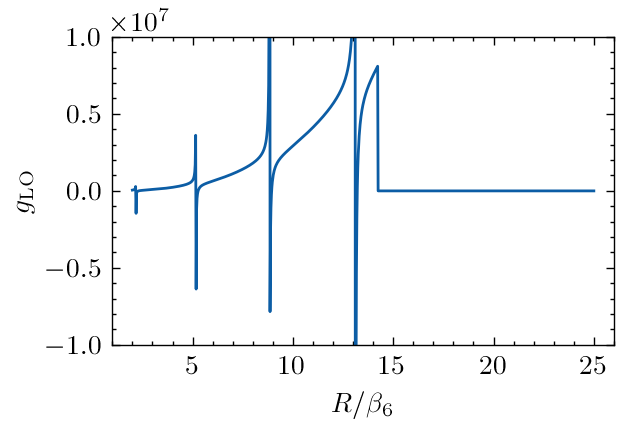

In [4]:
plt.plot(he4.BETA6/R_LO, gsLO)
plt.xlim(1.,26)
plt.ylim(-10000000,10000000)
plt.xlabel('$R/\\beta_6$')
plt.ylabel('$g_{\\rm LO}$')

In [292]:
np.savetxt('rg_flow_lo_nonlocal_2_8_8-physicalC6.txt', np.vstack((R_LO, gsLO)).T, header='R (Å)  g ()')

In [3]:
R_LO, gsLO = np.loadtxt('rg_flow_lo_nonlocal_2_8_8-physicalC6.txt',unpack=True)

# NLO renormalization

In [5]:
# First, we will tune k(cot(delta)). Then we'll go back and refine a_0 and r_0.
def kcd_diff(c_2s, sys, c_00):
    kcd = sys.kcotd_gen_pert1b_fast(momenta, c_00, *c_2s)
    return np.sum(((KCD - kcd)/KCD)**2)

def a0_diff(c_2s, sys, c_00):
    a0, r0 = sys.a0_and_r0_pert1b_fast(c_00, *c_2s, momenta)
    return he4.A0*(1/he4.A0 - 1/a0)

In [6]:
index = 10

print(R_LO[index])
s = he4.NonlocalHelium4System(R_LO[index], ELL, N1, N2, NCT)

2.410955644282401
Generating matrix elements for l = 0 and lp = 0.


In [7]:
s.a0_and_r0(gsLO[index], 0, momenta, use_c=True), s.bound_state_spectrum(gsLO[index], 0)

((100.00000000129651, 7.912123653770551),
 array([-1.32043855e-03, -1.47215518e+04]))

In [ ]:
s = he4.NonlocalHelium4System(R_LO[index], ELL, N1, N2, NCT)
#nlo_guess = result.x
c20 = 6673742.388473002
test = np.linspace(-100000,-150000,1200)

for i in range(len(test)):
#    result = minimize(lambda x: a0_diff([x,test[i]],s, gsLO[index]),-0.1,tol=1e-6)
    result = optimize.fsolve(lambda x: a0_diff([x,test[i]],s, gsLO[index]), c20,xtol=1e-8)
    c2s = np.array([*result, test[i]])
    atemp, rtemp= s.a0_and_r0_pert1b_fast(gsLO[index], *c2s, momenta)
    print(R_LO[index], gsLO[index],c2s[0],c2s[1],atemp,rtemp)
    c20 = c2s[0]+0.01*np.abs(c2s[0])

Generating matrix elements for l = 0 and lp = 0.
2.410955644282401 -64632.44533888187 6673742.388473002 -100000.0 100.00000007734856 7.74492857035488
2.410955644282401 -64632.44533888187 6676525.433674519 -100041.7014178482 100.00000001412353 7.744858059297482
2.410955644282401 -64632.44533888187 6679308.4787557 -100083.40283569641 99.99999999128984 7.74478918646617
2.410955644282401 -64632.44533888187 6682091.523970981 -100125.10425354462 100.00000002039958 7.744718451169753
2.410955644282401 -64632.44533888187 6684874.569186771 -100166.80567139282 100.00000008846703 7.744649042135064
2.410955644282401 -64632.44533888187 6687657.614265621 -100208.50708924103 99.9999998560012 7.744578894679348
2.410955644282401 -64632.44533888187 6690440.659544102 -100250.20850708924 99.99999997797671 7.7445086687295195
2.410955644282401 -64632.44533888187 6693223.7047561 -100291.90992493744 99.99999994348445 7.74443971079662
2.410955644282401 -64632.44533888187 6696006.749831039 -100333.61134278566 99

2.410955644282401 -64632.44533888187 6879687.731960394 -103085.90492076731 99.99999978981806 7.739757734721394
2.410955644282401 -64632.44533888187 6882470.777125465 -103127.60633861551 99.99999998371113 7.739688846715806
2.410955644282401 -64632.44533888187 6885253.822329399 -103169.30775646372 99.99999991844086 7.739619024210975
2.410955644282401 -64632.44533888187 6888036.867549764 -103211.00917431193 100.00000036222038 7.739549207550306
2.410955644282401 -64632.44533888187 6890819.912600446 -103252.71059216013 99.99999969509112 7.7394793400243875
2.410955644282401 -64632.44533888187 6893602.957785791 -103294.41201000834 100.00000013786108 7.739410228615869
2.410955644282401 -64632.44533888187 6896386.003028744 -103336.11342785654 100.0000000305491 7.739339872514542
2.410955644282401 -64632.44533888187 6899169.0482037375 -103377.81484570475 100.00000016918649 7.73927003951605
2.410955644282401 -64632.44533888187 6901952.093319964 -103419.51626355296 99.99999976957066 7.7391994917167

2.410955644282401 -64632.44533888187 7085633.075348263 -106171.80984153462 99.9999998626571 7.734589109426668
2.410955644282401 -64632.44533888187 7088416.120499335 -106213.51125938282 99.99999989290406 7.734518696736915
2.410955644282401 -64632.44533888187 7091199.165666779 -106255.21267723103 100.00000000636777 7.734449477055399
2.410955644282401 -64632.44533888187 7093982.210967535 -106296.91409507924 100.00000037645458 7.734378945648282
2.410955644282401 -64632.44533888187 7096765.256022319 -106338.61551292744 99.99999980260073 7.734308825809898
2.410955644282401 -64632.44533888187 7099548.301185046 -106380.31693077565 100.00000001045282 7.734240273030686
2.410955644282401 -64632.44533888187 7102331.3463268 -106422.01834862385 99.99999972221096 7.734169133484776
2.410955644282401 -64632.44533888187 7105114.391534657 -106463.71976647206 100.00000006057516 7.734100000894389
2.410955644282401 -64632.44533888187 7107897.4367420925 -106505.42118432026 100.00000010491571 7.73403002061642

2.410955644282401 -64632.44533888187 7291578.418713588 -109257.71476230191 99.9999999803788 7.729417934804731
2.410955644282401 -64632.44533888187 7294361.463906942 -109299.41618015012 99.99999981501007 7.72934794920676
2.410955644282401 -64632.44533888187 7297144.509202605 -109341.11759799832 100.00000034902227 7.7292781244696025
2.410955644282401 -64632.44533888187 7299927.554072175 -109382.81901584654 99.99999977940843 7.729208782352367
2.410955644282401 -64632.44533888187 7302710.599404829 -109424.52043369475 99.99999979630107 7.729138187807912
2.410955644282401 -64632.44533888187 7305493.644636694 -109466.22185154296 100.0000003682941 7.729068979638587
2.410955644282401 -64632.44533888187 7308276.68983011 -109507.92326939116 100.00000004577588 7.728998747389711
2.410955644282401 -64632.44533888187 7311059.735051893 -109549.62468723937 100.00000001377909 7.728928409536577
2.410955644282401 -64632.44533888187 7313842.780055326 -109591.32610508757 100.00000016000928 7.728859606307862

2.410955644282401 -64632.44533888187 7497523.761945177 -112343.61968306922 99.99999988586694 7.724246691558821
2.410955644282401 -64632.44533888187 7500306.807196729 -112385.32110091743 100.00000064621183 7.724177529520436
2.410955644282401 -64632.44533888187 7503089.852278908 -112427.02251876563 100.0000000449023 7.724107631260996
2.410955644282401 -64632.44533888187 7505872.8975009695 -112468.72393661384 99.99999965507243 7.724036536109323
2.410955644282401 -64632.44533888187 7508655.942602345 -112510.42535446206 100.00000003713556 7.723967506132829
2.410955644282401 -64632.44533888187 7511438.987860591 -112552.12677231026 100.00000007903432 7.72389793222454
2.410955644282401 -64632.44533888187 7514222.032988765 -112593.82819015847 99.9999996615961 7.723827708699286
2.410955644282401 -64632.44533888187 7517005.0783381825 -112635.52960800668 100.00000057438247 7.723757835578146
2.410955644282401 -64632.44533888187 7519788.123260256 -112677.23102585488 99.99999946510187 7.7236877079200

2.410955644282401 -64632.44533888187 7703469.105050637 -115429.52460383653 100.00000005703664 7.719075720518647
2.410955644282401 -64632.44533888187 7706252.150233496 -115471.22602168474 100.00000009375903 7.719005607901527
2.410955644282401 -64632.44533888187 7709035.195468699 -115512.92743953294 99.99999971098015 7.718935209897197
2.410955644282401 -64632.44533888187 7711818.240621604 -115554.62885738115 100.00000001419713 7.718865783095161
2.410955644282401 -64632.44533888187 7714601.285719482 -115596.33027522935 99.99999987694551 7.718795881675137
2.410955644282401 -64632.44533888187 7717384.331010864 -115638.03169307756 99.99999964320143 7.718725056814781
2.410955644282401 -64632.44533888187 7720167.3762423275 -115679.73311092576 100.00000009243675 7.7186557509517835
2.410955644282401 -64632.44533888187 7722950.421344912 -115721.43452877397 99.99999999881604 7.718585760562426
2.410955644282401 -64632.44533888187 7725733.466566678 -115763.13594662218 100.00000007002433 7.7185162992

2.410955644282401 -64632.44533888187 7909414.448158416 -118515.42952460384 99.99999981083042 7.713902974267814
2.410955644282401 -64632.44533888187 7912197.493458476 -118557.13094245204 100.00000040589156 7.713833518150073
2.410955644282401 -64632.44533888187 7914980.538537121 -118598.83236030025 99.99999974001338 7.713763059529874
2.410955644282401 -64632.44533888187 7917763.583918422 -118640.53377814846 100.0000002696585 7.713692535775796
2.410955644282401 -64632.44533888187 7920546.62888492 -118682.23519599666 99.9999997276713 7.713623388686382
2.410955644282401 -64632.44533888187 7923329.674207367 -118723.93661384487 100.00000023448136 7.7135529728056325
2.410955644282401 -64632.44533888187 7926112.719196508 -118765.63803169307 99.99999982681472 7.713483724476988
2.410955644282401 -64632.44533888187 7928895.764591478 -118807.33944954128 100.00000004500623 7.713412815569243
2.410955644282401 -64632.44533888187 7931678.809657228 -118849.04086738949 99.99999985849385 7.713343004597094

2.410955644282401 -64632.44533888187 8115359.791256808 -121601.33444537115 99.99999988431131 7.708729965006197
2.410955644282401 -64632.44533888187 8118142.83642286 -121643.03586321935 99.99999995987021 7.708659796262169
2.410955644282401 -64632.44533888187 8120925.88169095 -121684.73728106756 100.00000000294914 7.7085899816234775
2.410955644282401 -64632.44533888187 8123708.926839326 -121726.43869891576 99.99999994154228 7.708519943527059
2.410955644282401 -64632.44533888187 8126491.971991595 -121768.14011676397 99.99999986250424 7.708449601531947
2.410955644282401 -64632.44533888187 8129275.017175222 -121809.84153461218 99.99999993152483 7.70838013600946
2.410955644282401 -64632.44533888187 8132058.062379989 -121851.54295246038 100.00000019850859 7.708310520400524
2.410955644282401 -64632.44533888187 8134841.1074987305 -121893.24437030859 99.99999992536617 7.70824092264752
2.410955644282401 -64632.44533888187 8137624.1527289655 -121934.9457881568 99.9999999349385 7.708170437349328
2.

## Determine D-wave RG flow

We only consider the LO counterterm in the D-wave.